In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


In [31]:
%%bash

# Este script de bash se encarga de extraer una tabla de skyserver mediante una consulta SQL
ADQL="SELECT s.class, s.z, p.u, p.g FROM SpecObjAll AS s INNER JOIN dbo.fGetNearbyObjAllEq(135.5, 0.5, 30) AS n ON s.bestObjID = n.objID INNER JOIN PhotoObjAll AS p ON s.bestObjID = p.objID
"
QUERY=$(echo $ADQL | ./crear_query)
ENDPOINT="http://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd="

URL=${ENDPOINT}${QUERY}

wget2 -q -O datos.csv $URL

wc -l datos.csv

301 datos.csv


In [32]:
df = pd.read_csv('datos.csv', skiprows=1,)
print(df.head())


print(df.head())

df.describe()

    class         z         u         g
0  GALAXY  0.372134  22.89127  20.59739
1  GALAXY  0.372181  22.89127  20.59739
2  GALAXY  0.278896  20.71400  20.35820
3  GALAXY  0.278923  20.71400  20.35820
4  GALAXY  0.596284  26.22551  22.50839
    class         z         u         g
0  GALAXY  0.372134  22.89127  20.59739
1  GALAXY  0.372181  22.89127  20.59739
2  GALAXY  0.278896  20.71400  20.35820
3  GALAXY  0.278923  20.71400  20.35820
4  GALAXY  0.596284  26.22551  22.50839


,z,u,g
count,299.000000,299.000000,299.000000
mean,0.518767,22.017202,20.545664
std,0.792305,2.236638,1.935963
min,-0.000574,16.812400,15.773290
25%,0.012777,20.024025,18.903390
50%,0.299654,22.220260,20.842580
75%,0.559854,23.684085,22.140455
max,5.542272,27.284410,25.544310


In [33]:
# Limpieza de datos
df = df.dropna()
mascara = (df['z'] == -9999) | (df['u'] == -9999) | (df['g'] == -9999)
df_nuevo = df.drop(df[mascara].index, inplace=True)
df_nuevo = df.reset_index(drop=True)



In [34]:
# se define la columna color
df_nuevo['indice color'] = df_nuevo['u'] - df_nuevo['g']

df_nuevo.head()

,class,z,u,g,indice color
0,GALAXY,0.372134,22.89127,20.59739,2.29388
1,GALAXY,0.372181,22.89127,20.59739,2.29388
2,GALAXY,0.278896,20.71400,20.35820,0.35580
3,GALAXY,0.278923,20.71400,20.35820,0.35580
4,GALAXY,0.596284,26.22551,22.50839,3.71712


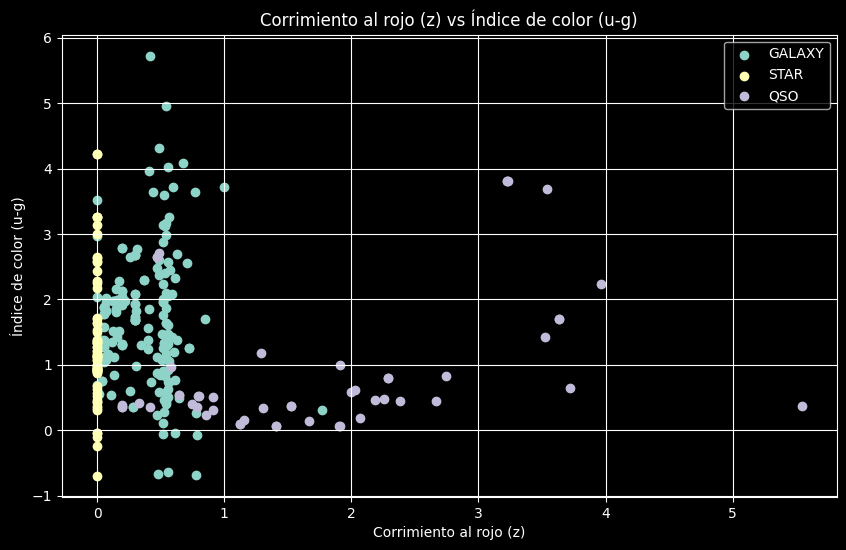

In [35]:
# Grafica de dispersión del corrimiento al rojo (z) vs el índice de color (u-g)
plt.figure(figsize=(10, 6))

# lo ponemos en apariencia oscura
plt.style.use('dark_background')

# separamos por clases (GALAXY, QSO, STAR)
for clase in df_nuevo['class'].unique():
    df_clase = df_nuevo[df_nuevo['class'] == clase]
    plt.scatter(df_clase['z'], df_clase['indice color'], alpha=1, marker='o', label=clase)


plt.title('Corrimiento al rojo (z) vs Índice de color (u-g)')
plt.xlabel('Corrimiento al rojo (z)')
plt.ylabel('Índice de color (u-g)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()
